# RNA para Clasificación con Iris — scikit-learn

Red neuronal artificial usando `sklearn.neural_network.MLPClassifier` para clasificar especies de flores Iris.

> **Nota:** Este notebook utiliza **exclusivamente scikit-learn**. No requiere TensorFlow ni Keras.

---

### Arquitectura de la red
```
Entrada (4) → Capa 1 (64, ReLU) → Capa 2 (32, ReLU) → Capa 3 (16, ReLU) → Salida (3, Softmax)
```

| Capa | Neuronas | Activación |
|------|----------|------------|
| Entrada | 4 | — |
| Oculta 1 | 64 | ReLU |
| Oculta 2 | 32 | ReLU |
| Oculta 3 | 16 | ReLU |
| Salida | 3 | Softmax (interno) |


## 1. Importar librerías


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente (sin TensorFlow)")


Librerías importadas correctamente (sin TensorFlow)


## 2. Cargar dataset

El dataset Iris contiene **150 muestras**, 4 features y 3 clases balanceadas.


In [22]:
data = load_iris()
X = data.data
y = data.target

print("Forma de X:", X.shape)
print("Clases:", data.target_names)
print("Distribución de clases:", dict(zip(data.target_names, np.bincount(y))))
print("\nFeatures:", data.feature_names)
print("\nEstadísticas descriptivas:")
print("  Media por feature: ", np.round(X.mean(axis=0), 2))
print("  Std  por feature:  ", np.round(X.std(axis=0), 2))
print(y)

Forma de X: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Distribución de clases: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Estadísticas descriptivas:
  Media por feature:  [5.84 3.06 3.76 1.2 ]
  Std  por feature:   [0.83 0.43 1.76 0.76]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## 3. Separar entrenamiento y validación

Se usa `stratify=y` para conservar la proporción de clases en ambas particiones.


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento : {X_train.shape[0]} muestras")
print(f"Validación    : {X_val.shape[0]} muestras")
print("Distribución train:", np.bincount(y_train))
print("Distribución val:  ", np.bincount(y_val))


Entrenamiento : 120 muestras
Validación    : 30 muestras
Distribución train: [40 40 40]
Distribución val:   [10 10 10]


## 4. Estandarización de features

`StandardScaler` ajusta **solo** con los datos de entrenamiento y luego transforma ambos conjuntos.
Esto evita *data leakage* del conjunto de validación.


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform en train
X_val   = scaler.transform(X_val)         # solo transform en validación

print("Datos estandarizados")
print("Media train (post-escala):", np.round(X_train.mean(axis=0), 4))
print("Std  train (post-escala):",  np.round(X_train.std(axis=0), 4))


Datos estandarizados
Media train (post-escala): [-0. -0.  0.  0.]
Std  train (post-escala): [1. 1. 1. 1.]


## 5. Arquitectura de la red neuronal

### Hiperparámetros principales

| Hiperparámetro | Valor | Descripción |
|----------------|-------|-------------|
| `hidden_layer_sizes` | `(64, 32, 16)` | 3 capas ocultas |
| `activation` | `relu` | Función de activación |
| `solver` | `adam` | Optimizador |
| `alpha` | `0.001` | Regularización L2 |
| `learning_rate_init` | `0.001` | Tasa de aprendizaje inicial |
| `max_iter` | `500` | Máximo de épocas |
| `early_stopping` | `True` | Detención temprana |
| `validation_fraction` | `0.1` | Fracción de val. interna |
| `n_iter_no_change` | `15` | Paciencia early stopping |
| `batch_size` | `auto` | Tamaño de mini-batch |


In [13]:
model = MLPClassifier(
    # --- Arquitectura ---
    hidden_layer_sizes=(64, 32, 16),   # 3 capas ocultas: 64 → 32 → 16 neuronas
    activation="relu",                 # ReLU en capas ocultas

    # --- Optimización ---
    solver="adam",                     # Optimizador Adam (adaptativo)
    learning_rate="adaptive",          # Reduce LR si el loss no mejora
    learning_rate_init=0.001,          # LR inicial
    batch_size="auto",                 # min(200, n_samples)

    # --- Regularización ---
    alpha=0.001,                       # Penalización L2 (weight decay)

    # --- Convergencia ---
    max_iter=500,
    tol=1e-4,

    # --- Early Stopping ---
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,

    random_state=42,
    verbose=False,
)

print("Arquitectura de la red:")
print(f"  Input  : 4 neuronas  (features)")
print(f"  Capa 1 : 64 neuronas (ReLU)")
print(f"  Capa 2 : 32 neuronas (ReLU)")
print(f"  Capa 3 : 16 neuronas (ReLU)")
print(f"  Output : 3 neuronas  (Softmax interno)")


Arquitectura de la red:
  Input  : 4 neuronas  (features)
  Capa 1 : 64 neuronas (ReLU)
  Capa 2 : 32 neuronas (ReLU)
  Capa 3 : 16 neuronas (ReLU)
  Output : 3 neuronas  (Softmax interno)


## 6. Entrenamiento


In [14]:
model.fit(X_train, y_train)

print(f"Entrenamiento completado")
print(f"Iteraciones realizadas : {model.n_iter_}")
print(f"Loss final (train)     : {model.loss_:.6f}")
best_loss = model.best_loss_ if model.best_loss_ is not None else 0.0
print(f"Best val loss          : {best_loss:.6f}")

Entrenamiento completado
Iteraciones realizadas : 62
Loss final (train)     : 0.328670
Best val loss          : 0.000000


## 7. Métricas de evaluación

Evaluamos con el conjunto de validación (datos que el modelo **no** vio durante el entrenamiento).


In [15]:
y_pred      = model.predict(X_val)
y_pred_prob = model.predict_proba(X_val)

accuracy  = model.score(X_val, y_val)
f1_macro  = f1_score(y_val, y_pred, average="macro")
f1_micro  = f1_score(y_val, y_pred, average="micro")
f1_weight = f1_score(y_val, y_pred, average="weighted")
roc_auc   = roc_auc_score(y_val, y_pred_prob, multi_class="ovr", average="macro")

print("=" * 40)
print("MÉTRICAS DE EVALUACIÓN")
print("=" * 40)
print(f"  Accuracy          : {accuracy:.4f}")
print(f"  F1-score macro    : {f1_macro:.4f}")
print(f"  F1-score micro    : {f1_micro:.4f}")
print(f"  F1-score weighted : {f1_weight:.4f}")
print(f"  ROC-AUC (OvR)     : {roc_auc:.4f}")
print("=" * 40)

print("\nReporte detallado por clase:")
print(classification_report(y_val, y_pred, target_names=data.target_names))


MÉTRICAS DE EVALUACIÓN
  Accuracy          : 0.8667
  F1-score macro    : 0.8611
  F1-score micro    : 0.8667
  F1-score weighted : 0.8611
  ROC-AUC (OvR)     : 0.9833

Reporte detallado por clase:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.60      0.75        10
   virginica       0.71      1.00      0.83        10

    accuracy                           0.87        30
   macro avg       0.90      0.87      0.86        30
weighted avg       0.90      0.87      0.86        30



## 8. Validación cruzada (5-fold)

Estima el rendimiento generalizable del modelo con mayor robustez.


In [16]:
# Reentrenamos sobre X completo estandarizado para CV
X_scaled = StandardScaler().fit_transform(X)

cv_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42,
)

cv_scores = cross_val_score(cv_model, X_scaled, y, cv=5, scoring="accuracy")

print("Validación cruzada 5-fold:")
print(f"  Scores por fold : {np.round(cv_scores, 4)}")
print(f"  Media           : {cv_scores.mean():.4f}")
print(f"  Desv. estándar  : {cv_scores.std():.4f}")


Validación cruzada 5-fold:
  Scores por fold : [0.3333 0.3333 0.3333 0.3333 0.3333]
  Media           : 0.3333
  Desv. estándar  : 0.0000


## 9. Búsqueda de hiperparámetros (GridSearchCV)

Comparamos distintas arquitecturas y tasas de regularización.


In [17]:
param_grid = {
    "hidden_layer_sizes": [(32, 16), (64, 32), (64, 32, 16), (128, 64, 32)],
    "alpha"             : [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
}

grid_model = MLPClassifier(
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    random_state=42,
)

grid_search = GridSearchCV(
    grid_model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_scaled, y)

print("Mejores hiperparámetros encontrados:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:25s}: {v}")
print(f"\n  Mejor accuracy (CV): {grid_search.best_score_:.4f}")


Mejores hiperparámetros encontrados:
  alpha                    : 0.01
  hidden_layer_sizes       : (128, 64, 32)
  learning_rate_init       : 0.01

  Mejor accuracy (CV): 0.9200


## 10. Visualizaciones

### 10a. Curva de pérdida durante entrenamiento


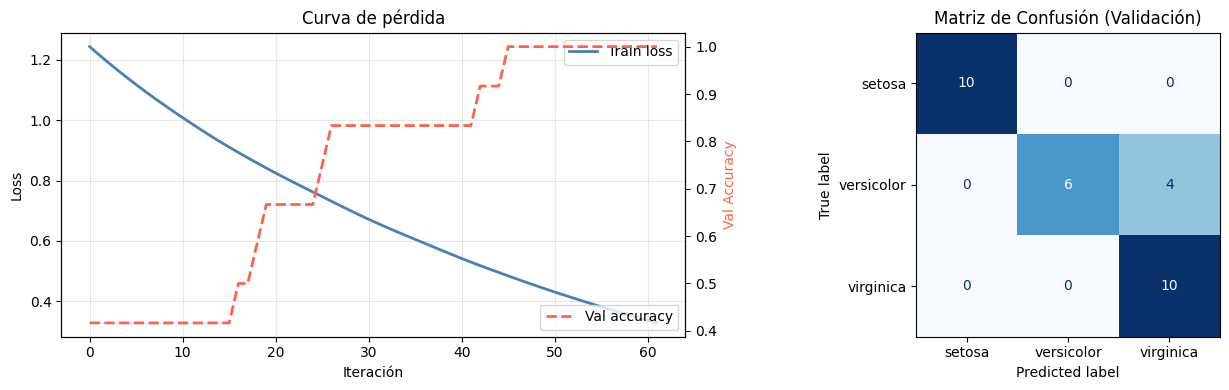

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Curva de pérdida ---
ax = axes[0]
if hasattr(model, "loss_curve_"):
    ax.plot(model.loss_curve_, label="Train loss", color="steelblue", linewidth=2)
    if hasattr(model, "validation_scores_") and model.validation_scores_:
        # validation_scores_ es accuracy, la graficamos en eje secundario
        ax2 = ax.twinx()
        ax2.plot(model.validation_scores_, label="Val accuracy",
                 color="tomato", linewidth=2, linestyle="--")
        ax2.set_ylabel("Val Accuracy", color="tomato")
        ax2.legend(loc="lower right")
ax.set_title("Curva de pérdida")
ax.set_xlabel("Iteración")
ax.set_ylabel("Loss")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# --- Matriz de confusión ---
ax = axes[1]
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusión (Validación)")

plt.tight_layout()
plt.show()


### 10b. Comparativa de arquitecturas (Grid Search)


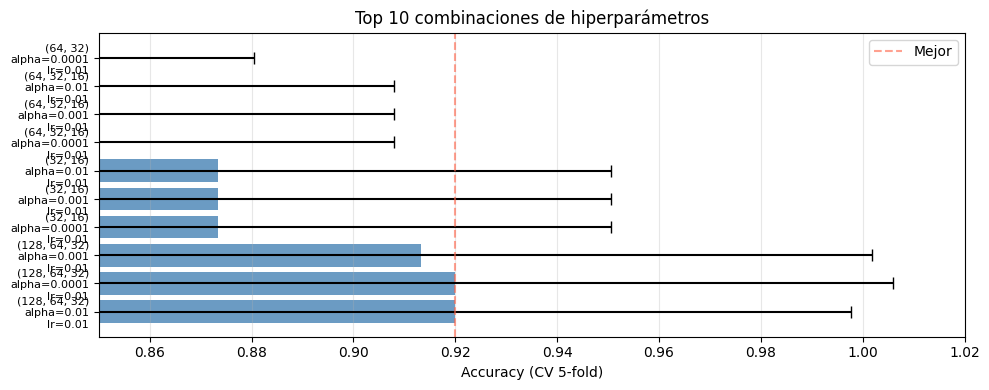

In [19]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)
top10 = results.sort_values("mean_test_score", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 4))
labels = [
    f"{str(r['param_hidden_layer_sizes'])}\nalpha={r['param_alpha']}\nlr={r['param_learning_rate_init']}"
    for _, r in top10.iterrows()
]
scores = top10["mean_test_score"].values
stds   = top10["std_test_score"].values

bars = ax.barh(range(len(scores)), scores, xerr=stds, color="steelblue",
               alpha=0.8, capsize=4)
ax.set_yticks(range(len(scores)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Accuracy (CV 5-fold)")
ax.set_title("Top 10 combinaciones de hiperparámetros")
ax.set_xlim(0.85, 1.02)
ax.axvline(x=scores[0], color="tomato", linestyle="--", alpha=0.6, label="Mejor")
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Predicción individual


In [20]:
idx = 0
muestra     = X_val[idx:idx+1]
pred        = model.predict(muestra)[0]
proba       = model.predict_proba(muestra)[0]
clase_real  = y_val[idx]

print(f"Muestra #{idx}")
print(f"  Clase real    : {data.target_names[clase_real]}")
print(f"  Clase predicha: {data.target_names[pred]}")
print(f"  Correcto      : {'✓' if pred == clase_real else '✗'}")
print("\nProbabilidades por clase:")
for nombre, p in zip(data.target_names, proba):
    barra = "█" * int(p * 30)
    print(f"  {nombre:12s}: {p:.4f}  {barra}")


Muestra #0
  Clase real    : setosa
  Clase predicha: setosa
  Correcto      : ✓

Probabilidades por clase:
  setosa      : 0.9558  ████████████████████████████
  versicolor  : 0.0336  █
  virginica   : 0.0106  


## 12. Resumen del modelo


In [21]:
# Conteo de parámetros entrenables
total_params = sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_)

print("=" * 45)
print("RESUMEN DEL MODELO")
print("=" * 45)
print(f"  Capas (incluyendo entrada/salida): {len(model.coefs_) + 1}")
for i, (W, b) in enumerate(zip(model.coefs_, model.intercepts_)):
    tipo = "Entrada→Oculta" if i == 0 else ("Oculta→Salida" if i == len(model.coefs_)-1 else f"Oculta {i}→{i+1}")
    print(f"  Capa {i+1} ({tipo:20s}): W={W.shape}, b={b.shape}  params={W.size + b.size}")
print(f"  {'─'*40}")
print(f"  Total parámetros entrenables: {total_params}")
print(f"  Iteraciones: {model.n_iter_}")
print(f"  Accuracy validación: {model.score(X_val, y_val):.4f}")
print("=" * 45)


RESUMEN DEL MODELO
  Capas (incluyendo entrada/salida): 5
  Capa 1 (Entrada→Oculta      ): W=(4, 64), b=(64,)  params=320
  Capa 2 (Oculta 1→2          ): W=(64, 32), b=(32,)  params=2080
  Capa 3 (Oculta 2→3          ): W=(32, 16), b=(16,)  params=528
  Capa 4 (Oculta→Salida       ): W=(16, 3), b=(3,)  params=51
  ────────────────────────────────────────
  Total parámetros entrenables: 2979
  Iteraciones: 62
  Accuracy validación: 0.8667
